# MPX Lesion Segmentation: Plots and Lesion Counting

- v1: Boxplots and BA comparison between ground truth (DWH), humans (ZC, AM), and algorithm.
- v2: Update for publication
    - Optimal threshold only
    - Histograms of counts per photo
    - Report mean and width for BA (plots in supplement?)
    - Supplement: DWH Mask vs DWH Count?
    - Table of patient characteristics (need from NIAID team)
    - Image overlay examples (color coded as before)
- v3: Update for JAMA Derm, with only plots to be used in manuscript
- v4: Iterating figure appearances based on co-author feedback. Also add exports for csv files for each figure, inclidng Dice and mask pixel counts (from which Dice is derived)

### Note on annotator names
- Rater 1 = Walker = DWH
- Rater 2 = Ziche = ZC
- Rater 3 = Andrew = AM

Last update 220607 AMcNeil

In [97]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Base oackages
import numpy as np
import matplotlib.pyplot as plt
import os

# I/O
import glob
from skimage import io
from PIL import Image
import h5py
import json

# Pytorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import ToTensor

# Data Augmentation
import imgaug as ia
import imgaug.augmenters as iaa
from imgaug.augmentables.segmaps import SegmentationMapsOnImage
ia.seed(2)

# Plots
import seaborn as sns
import pandas as pd
from textwrap import wrap
import matplotlib.patheffects as path_effects
import statsmodels.api as sm

# Measurements and Metrics
from sklearn import metrics as skmetrics
from skimage import measure

import scipy
from scipy.stats import pearsonr
from scipy.stats import linregress

random_state = np.random.RandomState(42)

In [98]:
torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [99]:
def path_join(folder_list):
    # Creates folder path from input list, including drive name
    k=0
    folder_path = str()
    for directory in folder_list:
        if k == 0:
            if len(directory) == 1 and directory != '.':
                folder_path += directory + ':' + os.sep
            else:
                folder_path += directory + os.sep
        else:
            folder_path += directory + os.sep
        k+=1
    
    return folder_path

---
## Set variables for data locations, names, etc.

In [100]:
# Data folder (laptop)
data_root = ''

save_root = r'.\final_Fusion_analysis' + os.sep
os.makedirs(save_root, exist_ok=True)

full_img_dir = data_root + 'final_Fusion_output' + os.sep

masked_img_dir = data_root + 'images_bgmasked' + os.sep

In [101]:
fontsize = 18
plt.rcParams.update({'font.size': fontsize})
default_fontsize = fontsize

In [102]:
def save_variable_to_json_file(variable,save_path):
    with open(save_path, 'w', encoding='utf-8') as f:
        json.dump(variable, f, ensure_ascii=False, indent=4)
    return

In [103]:
def load_json_file(path):
    with open(path, 'r', encoding='utf-8') as f:
        variable = json.load(f)
    return variable

---
## Create file lists

In [104]:
# Annotator counts (1st time)
count_mask_root = data_root + 'gt_counts' + os.sep
count_masks_AM = sorted(glob.glob(count_mask_root + 'AM' + os.sep + '**' + os.sep + '*.png', recursive=True))
count_masks_DWH = sorted(glob.glob(count_mask_root + 'DWH' + os.sep + '**' + os.sep + '*.png', recursive=True))
count_masks_ZC = sorted(glob.glob(count_mask_root + 'ZC' + os.sep + '**' + os.sep + '*.png', recursive=True))

# Annotator counts (2nd time)
repeat_count_mask_root = data_root + 'gt_counts' + os.sep + 'repeats' + os.sep
#count_masks_AM = sorted(glob.glob(count_mask_root + 'AM' + os.sep + '**' + os.sep + '*.png', recursive=True))
repeat_count_masks_DWH = sorted(glob.glob(repeat_count_mask_root + 'DWH' + os.sep + '**' + os.sep + '*.png', recursive=True))
#count_masks_ZC = sorted(glob.glob(count_mask_root + 'ZC' + os.sep + '**' + os.sep + '*.png', recursive=True))

In [105]:
dir_list = sorted(glob.glob(full_img_dir + os.sep + '*'))

h5_paths_dict = {}
patient_name_list = []
masked_img_dict = {}
for dir_no in range(len(dir_list)):
    directory = dir_list[dir_no]
    print(directory)
    patient_name = os.path.basename(directory)
    patient_name_list.extend([patient_name])
    
    h5_paths_dict[patient_name] = sorted(glob.glob(directory + os.sep + '*.h5'))
    masked_img_dict[patient_name] = sorted(glob.glob(masked_img_dir + patient_name + os.sep + '*.png'))

final_Fusion_output\051301
final_Fusion_output\051302
final_Fusion_output\051307
final_Fusion_output\051308
final_Fusion_output\051309
final_Fusion_output\051310
final_Fusion_output\213
final_Fusion_output\221
final_Fusion_output\227
final_Fusion_output\236
final_Fusion_output\238
final_Fusion_output\239
final_Fusion_output\247
final_Fusion_output\248
final_Fusion_output\Kole1
final_Fusion_output\Kole2
final_Fusion_output\Kole3
final_Fusion_output\MPX subject coming from Dekese (Not enrolled)


In [106]:
# dir_list = sorted(glob.glob(full_img_dir + os.sep + '*'))

# h5_paths_dict = {}
# patient_name_list = []
# masked_img_dict = {}
# for dir_no in range(len(dir_list)):
#     directory = dir_list[dir_no]
#     print(directory)
#     patient_name = os.path.basename(directory)
#     patient_name_list.extend([patient_name])
    
#     h5_paths_dict[patient_name] = sorted(glob.glob(directory + os.sep + '*.h5'))
#     masked_img_dict[patient_name] = sorted(glob.glob(masked_img_dir + patient_name + os.sep + '*.png'))

### Create Algorithm Counts

In [107]:
def segmentation_stats(gt_mask, pr_mask):
    stat_dict = {
        'DSC': np.around(skmetrics.f1_score(gt_mask.flatten(), pr_mask.flatten()),3),
        'ACC': np.around(skmetrics.accuracy_score(gt_mask.flatten(), pr_mask.flatten()),3),
        'gt_lesions': lesion_count(gt_mask),
        'pr_lesions': lesion_count(pr_mask)
    }
    
    return stat_dict

def lesion_count(binary_mask):
    mask_labelled = measure.label(binary_mask)
    lesion_number = len(np.unique(mask_labelled))-1
    
    return lesion_number

def majority_vote_mask(pr_map, threshold=0.5):
    max_val = np.max(pr_map)
    print('Max Val = ' + str(max_val))
    
    mv_mask = np.zeros(pr_map.shape,'bool')
    mv_mask[pr_map >= max_val*threshold] = True
    
    return mv_mask

## Save/Load algorithm results

In [108]:
def dice_masked(skin_masked_img, gt_mask, pr_mask, sigfig=3):
    # Create binary vectors for predicted and true masks
    gt_mask_vec = gt_mask.flatten().astype('bool')
    pr_mask_vec = pr_mask.flatten().astype('bool')
    
    # Create mask of the skin (removing non-skin background pixels from evaluation)
    skin_img = np.max(skin_masked_img,axis=2)
    skin_mask = np.zeros(skin_img.shape)
    skin_mask[skin_img > 0] = 1
    skin_mask_vec = skin_mask.flatten()
    
    # Calculate Dice
    DSC = skmetrics.f1_score(gt_mask_vec[skin_mask_vec==1], pr_mask_vec[skin_mask_vec==1],zero_division=1)
    
    return DSC, int(np.sum(gt_mask_vec[skin_mask_vec==1])), int(np.sum(pr_mask_vec[skin_mask_vec==1]))

---
### Counts and Dice

In [109]:
results_save = True
results_load = False

if results_save:
    algorithm_stats = {}
    for patient_name in h5_paths_dict:
        if h5_paths_dict[patient_name]:
            gt_counts = []
#             pr_mask_half_counts = []
            pr_mask_optimum_counts = []
            pr_mask_optimum_counts_masked = []
#             dice_half = []
            dice_optimum = []
            dice_optimum_masked = []
            pixel_counts_skin = []
            pixel_counts_gtMasked = []
            pixel_counts_prMasked = []
            img_name_list = []
            count_dict = {}
            for img_no in range(len(h5_paths_dict[patient_name])):
                # Load masks from h5 file
                with h5py.File(h5_paths_dict[patient_name][img_no], 'r') as hdf:
                    gt_mask = np.asarray(hdf['gt_mask'])
#                     pr_mask_half = np.asarray(hdf['pr_mask_half'])
                    pr_mask_optimum = np.asarray(hdf['pr_mask_optimum'])
#                     rec_count = np.asarray(hdf['lesion_count'])
                
                masked_img = np.asarray(Image.open(masked_img_dict[patient_name][img_no]))[:,:,0:3]
                
                skin_map = np.zeros(masked_img.shape)
                skin_map[masked_img > 0] = 1
                skin_mask = skin_map[:,:,0].astype('bool')
                
                print(skin_mask.shape)
                pr_mask_optimum_bgmasked = pr_mask_optimum.copy()
                pr_mask_optimum_bgmasked[skin_mask == False] = 0
                
                curent_filename = os.path.basename(h5_paths_dict[patient_name][img_no]).split('_PredictionResults')[0]

                gt_counts.extend([lesion_count(gt_mask)])
#                 pr_mask_half_counts.extend([lesion_count(pr_mask_half)])
                pr_mask_optimum_counts.extend([lesion_count(pr_mask_optimum_bgmasked)])
#                 pr_mask_optimum_counts_masked.extend([int(rec_count)])
                img_name_list.extend([curent_filename])

                #Dice, for comparison
#                 dice_half.extend([np.around(skmetrics.f1_score(gt_mask.flatten().astype('bool'), pr_mask_half.flatten().astype('bool')),3)])
                dice_optimum.extend([np.around(skmetrics.f1_score(gt_mask.flatten().astype('bool'), pr_mask_optimum.flatten().astype('bool')),3)])
                
                # Masked Dice
                masked_dice, masked_gt_pixel_count, masked_pr_pixel_count = dice_masked(masked_img, gt_mask, pr_mask_optimum)
                dice_optimum_masked.extend([masked_dice])
                
                # Pixel Counts
                pixel_counts_skin.extend([float(np.sum(skin_mask.flatten()))])
                pixel_counts_gtMasked.extend([float(masked_gt_pixel_count)])
                pixel_counts_prMasked.extend([float(masked_pr_pixel_count)])
            
            count_dict['Image Names'] = img_name_list
            count_dict['gt_counts'] = gt_counts
#             count_dict['pr_mask_half_counts'] = pr_mask_half_counts
            count_dict['pr_mask_optimum_counts'] = pr_mask_optimum_counts
            count_dict['pr_mask_optimum_counts_masked'] = pr_mask_optimum_counts_masked
#             count_dict['dice_half'] = dice_half
            count_dict['dice_optimum'] = dice_optimum
            count_dict['dice_optimum_masked'] = dice_optimum_masked
            count_dict['Total Pixels: Skin'] = pixel_counts_skin
            count_dict['Total Pixels: Ground Truth Lesions'] = pixel_counts_gtMasked
            count_dict['Total Pixels: Predicted Lesions'] = pixel_counts_prMasked
            
            algorithm_stats[patient_name] = count_dict
    
    with open(save_root + '220607_MPX_JAMADerm_v4_seg_stats.json', 'w', encoding='utf-8') as f:
        json.dump(algorithm_stats, f, ensure_ascii=False, indent=4)

if results_load:
    with open(save_root + '220607_MPX_JAMADerm_v4_seg_stats.json', 'r', encoding='utf-8') as f:
        algorithm_stats = json.load(f)

(1024, 768)
(1024, 768)
(768, 1024)
(768, 1024)
(1024, 768)
(1024, 768)
(768, 1024)
(768, 1024)
(1024, 768)
(1024, 768)
(1024, 768)
(1024, 768)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(1024, 768)
(1024, 768)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(768, 1024)
(1024, 768)
(1024, 768)
(768, 1024)
(1024, 768)
(1024, 768)
(1024, 768)
(1024, 768)
(1024, 768)
(768, 1024)
(768, 1024)


---
### Plot functions

In [110]:
def boxplot_full_set_v2(df,
                        colors = ["lightgreen", "lightyellow"],
                        figsize=(4.5,9),
                        median_labels = True,
                        swarmsize=6,
                        swarmpalette=['0.25','0.25'],
                        swarm_marker='o',
                        ylim=(-0.05,1.05),
                        fontsize=None,
                        savefig=False,
                        showfig=True,
                        savename='boxplot_v2',
                        gridlines="both",
                        title="Boxplot v2",
                        titlewrap=35,
                        xlabel='Group',
                        xlabel_size = None,
                        xtick_rotation = 0,
                        ylabel="Value",
                        ylabel_size = None,
                        y_axis_right=False,
                        median_color='white',
                        median_outline=False,
                        median_outline_color ='black',
                        median_fontsize=None,
                        show_means=False,
                        meanline=False,
                        meanprops={"marker":"o",
                                   "markerfacecolor":"white", 
                                   "markeredgecolor":"red",
                                   "markersize":"16"}
                       ):
    
    sns.set_palette(sns.color_palette(colors))
    sns.set_style("whitegrid", {"axes.grid.which":gridlines})
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': fontsize})
        
    plt.figure(figsize=figsize)
        
    ax = sns.swarmplot(data=df,
                       #color=".25",
                       palette=swarmpalette,
                       size=swarmsize,
                       marker=swarm_marker)
    
    if show_means and meanline:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanline=True,
                         meanprops=meanprops
                        )
        print('meanline!')
    elif show_means:
        ax = sns.boxplot(data=df,
                         fliersize=0,
                         showmeans=True,
                         meanprops=meanprops
                        )
    
    else:
        ax = sns.boxplot(data=df,fliersize=0)
    
    if median_labels:
        add_median_labels(ax, median_color, median_outline_color, median_fontsize, median_outline=median_outline)

    plt.ylim(ylim)
    
    plt.title("\n".join(wrap(title,titlewrap)))
    
    if xlabel_size is None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(xlabel, fontsize=xlabel_size)
    
    if ylabel_size is None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel(ylabel, fontsize=ylabel_size)
    
    if y_axis_right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
    
    plt.xticks(rotation = xtick_rotation)
    
    if savefig:
        plt.savefig(savename + '.png', dpi=150, bbox_inches='tight')
        plt.savefig(savename + '.pdf', dpi=150, bbox_inches='tight')
    
    if showfig:
        plt.show()
    else:
        plt.close()
    
    if fontsize is not None:
        plt.rcParams.update({'font.size': default_fontsize})

In [111]:
def add_median_labels(ax,color='white',foreground_color='white',fontsize=None,median_outline=False):
    lines = ax.get_lines()
    # determine number of lines per box (this varies with/without fliers)
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    lines_per_box = int(len(lines) / len(boxes))
    # iterate over median lines
    median_list = []
    for median in lines[4:len(lines):lines_per_box]:
        # display median value at center of median line
        x, y = (data.mean() for data in median.get_data())
        # choose value depending on horizontal or vertical plot orientation
        value = x if (median.get_xdata()[1]-median.get_xdata()[0]) == 0 else y
        if fontsize is not None:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color, fontsize=fontsize)
        else:
            text = ax.text(x, y, f'{value:.2f}', ha='center', va='center',
                           fontweight='bold', color=color)
        
        if median_outline:
            # create median-colored border around white text for contrast
            text.set_path_effects([
                path_effects.Stroke(linewidth=3, foreground=foreground_color),#median.get_color()),
                path_effects.Normal(),
            ])
        median_list.extend([value])
    return median_list

---
## Count lesions for all annotators

In [112]:
def count_all_lesions(mask_location_list):
    lesion_counts = []

    for image in mask_location_list:
        mask = np.max(io.imread(image),2).astype('bool')
        lesion_counts.extend([lesion_count(mask)])
    
    return lesion_counts

In [113]:
def image_name_list_creator(mask_location_list, separator='_AM'):
    image_name_list = []
    
    for image in mask_location_list:
        image_name_list.extend([os.path.basename(image).split(separator)[0]])
    
    return image_name_list

In [114]:
gt_count_list = []
# pr_lesion_half_list = []
pr_lesion_optimum_list = []
# dice_half_list = []
dice_optimum_list = []
image_name_list = []
pr_lesion_optimum_masked_list = []
pixel_counts_skin_list = []
pixel_counts_gtMasked_list = []
pixel_counts_prMasked_list = []
for key in algorithm_stats:
    gt_count_list.extend(algorithm_stats[key]['gt_counts'])
#     pr_lesion_half_list.extend(algorithm_stats[key]['pr_mask_half_counts'])
    pr_lesion_optimum_list.extend(algorithm_stats[key]['pr_mask_optimum_counts'])
    pr_lesion_optimum_masked_list.extend(algorithm_stats[key]['pr_mask_optimum_counts_masked'])
#     dice_half_list.extend(algorithm_stats[key]['dice_half'])
    dice_optimum_list.extend(algorithm_stats[key]['dice_optimum'])
    image_name_list.extend(algorithm_stats[key]['Image Names'])
    
    pixel_counts_skin_list.extend(algorithm_stats[key]['Total Pixels: Skin'])
    pixel_counts_gtMasked_list.extend(algorithm_stats[key]['Total Pixels: Ground Truth Lesions'])
    pixel_counts_prMasked_list.extend(algorithm_stats[key]['Total Pixels: Predicted Lesions'])

### Save/Load lesion count dict

In [115]:
print(len(image_name_list))
print(len(count_all_lesions(count_masks_AM)))
print(len(count_all_lesions(count_masks_DWH)))
print(len(count_all_lesions(count_masks_ZC)))
print(len(count_all_lesions(repeat_count_masks_DWH)))
print(len(gt_count_list))

66
66
66
66
66
66


In [116]:
lesion_count_dict_save = False
lesion_count_dict_load = False

if not lesion_count_dict_load:
    lesion_count_dict = {
        'Image Names': image_name_list,
        'Rater 3': count_all_lesions(count_masks_AM),
        'Rater 1': count_all_lesions(count_masks_DWH),
        'Rater 2': count_all_lesions(count_masks_ZC),
        'Rater 1 Repeat': count_all_lesions(repeat_count_masks_DWH),
        'Rater 1 Segmentation Counts': gt_count_list,
    }
    if lesion_count_dict_save:
        save_variable_to_json_file(lesion_count_dict, save_root + '220607_MPX_JAMADerm_v4_lesion_count_dict.json')

if lesion_count_dict_load:
    lesion_count_dict = load_json_file(save_root + '220607_MPX_JAMADerm_v4_lesion_count_dict.json')

# print(len(lesion_count_dict['Rater 1']))
lesion_counts_df = pd.DataFrame.from_dict(lesion_count_dict)
lesion_counts_df

,Image Names,Rater 3,Rater 1,Rater 2,Rater 1 Repeat,Rater 1 Segmentation Counts
0,051301 D2_06,30,30,33,32,33
1,051301 D2_07,72,59,70,70,74
2,051301 D2_08,56,44,54,49,60
3,051301 D8_02,143,137,134,138,151
4,051302 D2_01,135,27,17,28,35
5,051302 D2_02,100,39,15,38,27
6,051307 010,21,20,17,14,25
7,051307 012,22,11,18,16,20
8,051308 001,94,94,85,95,93
9,051308 004,46,44,41,46,43


In [117]:
save_algo_comparison_counts_to_csv = True

algo_comparison_counts_df = lesion_counts_df.loc[lesion_counts_df['Image Names'].isin(image_name_list)].copy()
# algo_comparison_counts_df['AI (0.5 Threshold)'] = pr_lesion_half_list
algo_comparison_counts_df['AI (Optimal Threshold)'] = pr_lesion_optimum_list
# algo_comparison_counts_df['AI Opti Masked'] = pr_lesion_optimum_masked_list

if save_algo_comparison_counts_to_csv:
    algo_comparison_counts_df.to_csv(save_root + '220607_MPX_JAMADerm_N18_v6_lesion_counts.csv',index=False)

In [118]:
pd.set_option('display.max_rows', 100)
algo_comparison_counts_df

,Image Names,Rater 3,Rater 1,Rater 2,Rater 1 Repeat,Rater 1 Segmentation Counts,AI (Optimal Threshold)
0,051301 D2_06,30,30,33,32,33,26
1,051301 D2_07,72,59,70,70,74,63
2,051301 D2_08,56,44,54,49,60,24
3,051301 D8_02,143,137,134,138,151,126
4,051302 D2_01,135,27,17,28,35,33
5,051302 D2_02,100,39,15,38,27,27
6,051307 010,21,20,17,14,25,22
7,051307 012,22,11,18,16,20,16
8,051308 001,94,94,85,95,93,67
9,051308 004,46,44,41,46,43,46


## Count Histograms

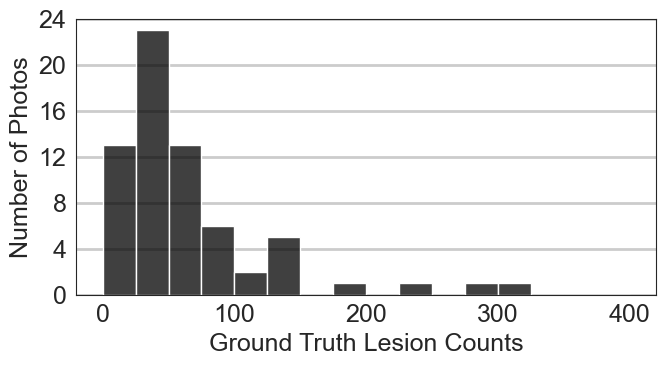

In [119]:
savename = '220605_MPX_JAMADerm_N18_v6_histogram_of_counts_v4'
savefig = False
showfig = True

sns.set_style("white")

plt.figure(figsize=(7,4))

sns.histplot(algo_comparison_counts_df['Rater 1'],binwidth=25,binrange=(0,400),color='0.0')
plt.ylabel('Number of Photos')
plt.xlabel('Ground Truth Lesion Counts')
plt.ylim([0,24])
plt.yticks([0,4,8,12,16,20,24])
plt.grid(axis='y',linestyle='-', linewidth=2)

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

In [120]:
display(algo_comparison_counts_df['Rater 1'].quantile([0,0.25,0.5,0.75,1]))
print(np.mean(algo_comparison_counts_df['Rater 1']))
print(np.std(algo_comparison_counts_df['Rater 1']))

0.00      7.00
0.25     27.50
0.50     44.00
0.75     80.75
1.00    304.00
Name: Rater 1, dtype: float64

63.96969696969697
58.83566473970289


## Bland-Altmans

In [121]:
from statsmodels.graphics import utils

In [122]:
def f_test(x, y):
    x = np.array(x)
    y = np.array(y)
    f = np.var(x, ddof=1)/np.var(y, ddof=1) #calculate F test statistic 
    dfn = x.size-1 #define degrees of freedom numerator 
    dfd = y.size-1 #define degrees of freedom denominator 
    p = 1-scipy.stats.f.cdf(f, dfn, dfd) #find p-value of F test statistic 
    return f, p

In [123]:
## Custom BA from statsmodels

def mean_diff_plot_v2(m1, m2, sd_limit=1.96, ax=None, scatter_kwds=None,
                      mean_line_kwds=None, limit_lines_kwds=None,
                      axis_fontsize=15,
                      annotate_fontsize=14,
                      tick_fontsize=13
                     ):
    """
    Construct a Tukey/Bland-Altman Mean Difference Plot.

    Tukey's Mean Difference Plot (also known as a Bland-Altman plot) is a
    graphical method to analyze the differences between two methods of
    measurement. The mean of the measures is plotted against their difference.

    For more information see
    https://en.wikipedia.org/wiki/Bland-Altman_plot

    Parameters
    ----------
    m1 : array_like
        A 1-d array.
    m2 : array_like
        A 1-d array.
    sd_limit : float
        The limit of agreements expressed in terms of the standard deviation of
        the differences. If `md` is the mean of the differences, and `sd` is
        the standard deviation of those differences, then the limits of
        agreement that will be plotted are md +/- sd_limit * sd.
        The default of 1.96 will produce 95% confidence intervals for the means
        of the differences. If sd_limit = 0, no limits will be plotted, and
        the ylimit of the plot defaults to 3 standard deviations on either
        side of the mean.
    ax : AxesSubplot
        If `ax` is None, then a figure is created. If an axis instance is
        given, the mean difference plot is drawn on the axis.
    scatter_kwds : dict
        Options to to style the scatter plot. Accepts any keywords for the
        matplotlib Axes.scatter plotting method
    mean_line_kwds : dict
        Options to to style the scatter plot. Accepts any keywords for the
        matplotlib Axes.axhline plotting method
    limit_lines_kwds : dict
        Options to to style the scatter plot. Accepts any keywords for the
        matplotlib Axes.axhline plotting method

    Returns
    -------
    Figure
        If `ax` is None, the created figure.  Otherwise the figure to which
        `ax` is connected.

    References
    ----------
    Bland JM, Altman DG (1986). "Statistical methods for assessing agreement
    between two methods of clinical measurement"

    Examples
    --------

    Load relevant libraries.

    >>> import statsmodels.api as sm
    >>> import numpy as np
    >>> import matplotlib.pyplot as plt

    Making a mean difference plot.

    >>> # Seed the random number generator.
    >>> # This ensures that the results below are reproducible.
    >>> np.random.seed(9999)
    >>> m1 = np.random.random(20)
    >>> m2 = np.random.random(20)
    >>> f, ax = plt.subplots(1, figsize = (8,5))
    >>> sm.graphics.mean_diff_plot(m1, m2, ax = ax)
    >>> plt.show()

    .. plot:: plots/graphics-mean_diff_plot.py
    """
    fig, ax = utils.create_mpl_ax(ax)

    if len(m1) != len(m2):
        raise ValueError('m1 does not have the same length as m2.')
    if sd_limit < 0:
        raise ValueError('sd_limit ({}) is less than 0.'.format(sd_limit))

    means = np.mean([m1, m2], axis=0)
    diffs = m1 - m2
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs, axis=0)

    scatter_kwds = scatter_kwds or {}
    if 's' not in scatter_kwds:
        scatter_kwds['s'] = 20
    mean_line_kwds = mean_line_kwds or {}
    limit_lines_kwds = limit_lines_kwds or {}
    for kwds in [mean_line_kwds, limit_lines_kwds]:
        if 'color' not in kwds:
            kwds['color'] = 'gray'
        if 'linewidth' not in kwds:
            kwds['linewidth'] = 1
    if 'linestyle' not in mean_line_kwds:
        kwds['linestyle'] = '--'
    if 'linestyle' not in limit_lines_kwds:
        kwds['linestyle'] = ':'

    ax.scatter(means, diffs, **scatter_kwds) # Plot the means against the diffs.
    ax.axhline(mean_diff, **mean_line_kwds)  # draw mean line.

    # Annotate mean line with mean difference.
#     ax.annotate('Bias:{}'.format(np.round(mean_diff, 2)),
#                 xy=(0.99, 0.5),
#                 horizontalalignment='right',
#                 verticalalignment='center',
#                 fontsize=annotate_fontsize,
#                 xycoords='axes fraction')

    if sd_limit > 0:
        half_ylim = (1.5 * sd_limit) * std_diff
        ax.set_ylim(mean_diff - half_ylim,
                    mean_diff + half_ylim)
        limit_of_agreement = sd_limit * std_diff
        lower = mean_diff - limit_of_agreement
        upper = mean_diff + limit_of_agreement
        for j, lim in enumerate([lower, upper]):
            ax.axhline(lim, **limit_lines_kwds)
#         ax.annotate(f'-{sd_limit} SD: {lower:0.2g}',
#                     xy=(0.99, 0.07),
#                     horizontalalignment='right',
#                     verticalalignment='bottom',
#                     fontsize=annotate_fontsize,
#                     xycoords='axes fraction')
#         ax.annotate(f'+{sd_limit} SD: {upper:0.2g}',
#                     xy=(0.99, 0.92),
#                     horizontalalignment='right',
#                     fontsize=annotate_fontsize,
#                     xycoords='axes fraction')

    elif sd_limit == 0:
        half_ylim = 3 * std_diff
        ax.set_ylim(mean_diff - half_ylim,
                    mean_diff + half_ylim)

    ax.set_ylabel('Difference', fontsize=axis_fontsize)
    ax.set_xlabel('Means', fontsize=axis_fontsize)
    ax.tick_params(labelsize=tick_fontsize)
    fig.tight_layout()
    
    print('Upper LoA: '+str(upper))
    print('Lower LoA: '+str(lower))
    print('Bias: '+str(mean_diff))
    return fig

Upper LoA: 21.676405855041203
Lower LoA: -45.7673149459503
Bias: -12.045454545454545


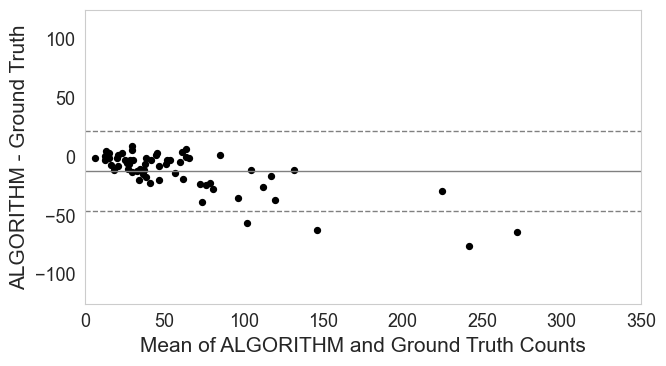

In [124]:
savename = '220604_MPX_JAMADerm_N18_v6_BA_ALGORITHM_Rater1_v4'
savefig = False
showfig = True

sns.set_style("whitegrid", {'axes.grid' : False})
scatter_kwds = {
    's': 18,''
    'c': 'black'
}

# tmp_algo_count = list(algo_comparison_counts_df['AI (Optimal Threshold)'])
# del tmp_algo_count[-7:-4]
# tmp_rater_count = list(algo_comparison_counts_df['Rater 1'])
# del tmp_rater_count[-7:-4]

f, ax = plt.subplots(1, figsize = (7,4))
mean_diff_plot_v2(np.asarray(algo_comparison_counts_df['AI (Optimal Threshold)']), #.drop([56,57,58,59,60,61,62,63])
                           np.asarray(algo_comparison_counts_df['Rater 1']),
                           ax = ax,scatter_kwds=scatter_kwds)
# mean_diff_plot_v2(np.asarray(tmp_algo_count), #.drop([56,57,58,59,60,61,62,63])
#                            np.asarray(tmp_rater_count),
#                            ax = ax,scatter_kwds=scatter_kwds)

plt.title('')
plt.xlim([0,350])
plt.ylim([-125,125])
plt.ylabel('ALGORITHM - Ground Truth')
plt.xlabel('Mean of ALGORITHM and Ground Truth Counts')

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

KeyError: 'AI Opti Masked'

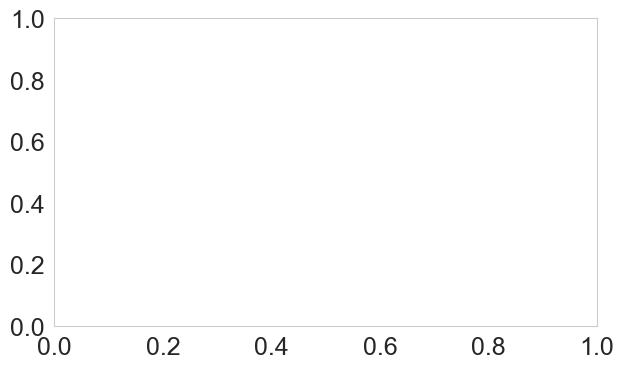

In [62]:
### MASKED VERSION

savename = '220607_MPX_JAMADerm_N18_v6_BA_ALGORITHM-masked_Rater1_v4'
savefig = False
showfig = True

sns.set_style("whitegrid", {'axes.grid' : False})
scatter_kwds = {
    's': 18,
    'c': 'black'
}

f, ax = plt.subplots(1, figsize = (7,4))
mean_diff_plot_v2(np.asarray(algo_comparison_counts_df['AI Opti Masked']),#.drop([56,57,58,59,60,61,62,63])
                  np.asarray(algo_comparison_counts_df['Rater 1']),
                  ax = ax,scatter_kwds=scatter_kwds)

plt.title('')
plt.xlim([0,350])
plt.ylim([-125,125])
plt.ylabel('ALGORITHM - Ground Truth')
plt.xlabel('Mean of ALGORITHM and Ground Truth Counts')

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

In [51]:
# Save differences for each photo to file if desired (for manual checking)
if False:
    AI_1_differences_df = pd.DataFrame(
        {
            'Names':algo_comparison_counts_df['Image Names'],
            'Differences':algo_comparison_counts_df['AI (Optimal Threshold)']-algo_comparison_counts_df['Rater 1']
        }
    )
    AI_1_differences_df.to_csv('AI_1_differences_df_v6.csv',index=False)

Upper LoA: 15.97690758483068
Lower LoA: -22.461756069679165
Bias: -3.242424242424242


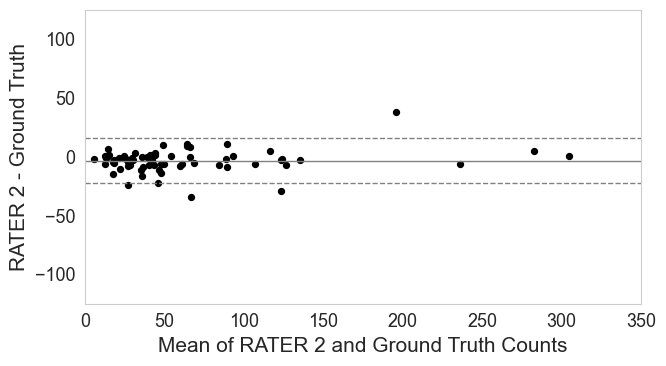

In [52]:
savename = '220607_MPX_JAMADerm_N18_v6_BA_Rater2_Rater1_v4'
savefig = False
showfig = True

sns.set_style("whitegrid", {'axes.grid' : False})
scatter_kwds = {
    's': 18,
    'c': 'black'
}

f, ax = plt.subplots(1, figsize = (7,4))
mean_diff_plot_v2(np.asarray(algo_comparison_counts_df['Rater 2']),
                  np.asarray(algo_comparison_counts_df['Rater 1']),
                  ax = ax,scatter_kwds=scatter_kwds)

plt.title('')
plt.xlim([0,350])
plt.ylim([-125,125])
plt.ylabel('RATER 2 - Ground Truth')
plt.xlabel('Mean of RATER 2 and Ground Truth Counts')

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

Upper LoA: 48.05215329997801
Lower LoA: -28.68851693634165
Bias: 9.681818181818182


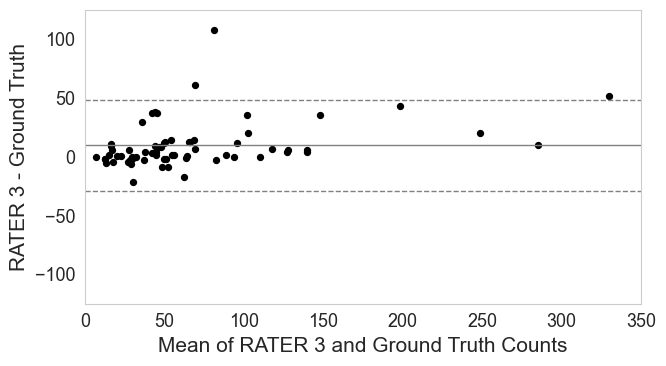

In [53]:
savename = '220607_MPX_JAMADerm_N18_v6_BA_Rater3_Rater1_v5'
savefig = False
showfig = True

sns.set_style("whitegrid", {'axes.grid' : False})
scatter_kwds = {
    's': 18,
    'c': 'black'
}

f, ax = plt.subplots(1, figsize = (7,4))
mean_diff_plot_v2(np.asarray(algo_comparison_counts_df['Rater 3']),
                  np.asarray(algo_comparison_counts_df['Rater 1']),
                  ax = ax,scatter_kwds=scatter_kwds)

plt.title('')
plt.xlim([0,350])
plt.ylim([-125,125])
plt.ylabel('RATER 3 - Ground Truth')
plt.xlabel('Mean of RATER 3 and Ground Truth Counts')

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

Upper LoA: 53.88196239224166
Lower LoA: -28.033477543756817
Bias: 12.924242424242424


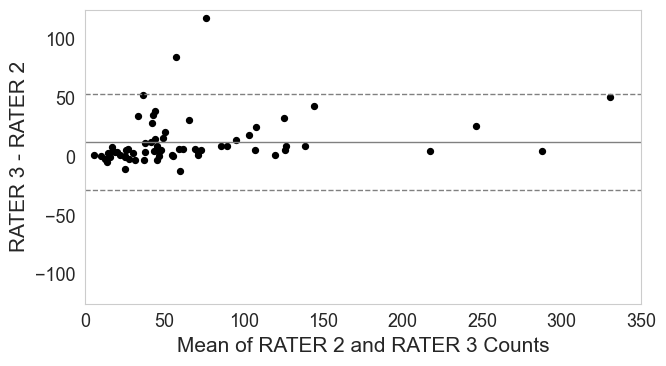

In [54]:
savename = '220607_MPX_JAMADerm_N18_v6_BA_Rater2_Rater3_v5'
savefig = False
showfig = True

sns.set_style("whitegrid", {'axes.grid' : False})
scatter_kwds = {
    's': 18,
    'c': 'black'
}

f, ax = plt.subplots(1, figsize = (7,4))
mean_diff_plot_v2(np.asarray(algo_comparison_counts_df['Rater 3']),
                  np.asarray(algo_comparison_counts_df['Rater 2']),
                  ax = ax,scatter_kwds=scatter_kwds)

plt.title('')
plt.xlim([0,350])
plt.ylim([-125,125])
plt.ylabel('RATER 3 - RATER 2')
plt.xlabel('Mean of RATER 2 and RATER 3 Counts')

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

## Scatter plots

y = 0.8x + 3.31
R^2 = 0.95


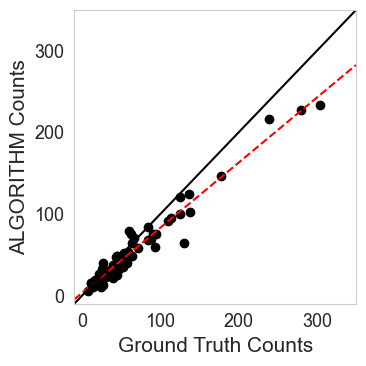

In [55]:
sns.set_style("whitegrid", {'axes.grid' : False})

axis_lim = [-10,350]

# Algorithm
savename = '220605_MPX_JAMADerm_N18_v6_Scatter_AI_RaterA_v4'
savefig = False
showfig = True

#Regression line
linear_regress_fit = linregress(algo_comparison_counts_df['Rater 1'],
                                algo_comparison_counts_df['AI (Optimal Threshold)'])
x_scatter_line = np.asarray(axis_lim)
y_scatter_line = linear_regress_fit.slope*x_scatter_line + linear_regress_fit.intercept

print('y = '+str(np.around(linear_regress_fit.slope,2))+'x + '+str(np.around(linear_regress_fit.intercept,2)))
print('R^2 = '+str(np.around(linear_regress_fit.rvalue**2,2)))

plt.figure(figsize=(4,4))

plt.scatter(algo_comparison_counts_df['Rater 1'],
            algo_comparison_counts_df['AI (Optimal Threshold)'],
            color="0.0")

plt.plot(x_scatter_line,
         y_scatter_line,color="red",linestyle='--')

plt.plot(axis_lim,axis_lim,'k-')

plt.xlabel("Ground Truth Counts", fontsize=15)
plt.ylabel("ALGORITHM Counts", fontsize=15)
plt.xlim(axis_lim)
plt.ylim(axis_lim)
plt.yticks([0,100,200,300])
plt.xticks([0,100,200,300])

plt.tick_params(labelsize=13)

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

In [56]:
## BG MASKED VERSION
sns.set_style("whitegrid", {'axes.grid' : False})

axis_lim = [0,350]

# Algorithm
savename = '220605_MPX_JAMADerm_N18_v6_Scatter_AI-masked_Rater1_v4'
savefig = False
showfig = True

#Regression line
linear_regress_fit = linregress(algo_comparison_counts_df['Rater 1'],
                                algo_comparison_counts_df['AI Opti Masked'])
x_scatter_line = np.asarray(axis_lim)
y_scatter_line = linear_regress_fit.slope*x_scatter_line + linear_regress_fit.intercept

print('y = '+str(np.around(linear_regress_fit.slope,2))+'x + '+str(np.around(linear_regress_fit.intercept,2)))
print('R^2 = '+str(np.around(linear_regress_fit.rvalue**2,2)))

plt.figure(figsize=(4,4))

plt.scatter(algo_comparison_counts_df['Rater 1'],
            algo_comparison_counts_df['AI Opti Masked'],
            color="0.0",
            s=12
           )

plt.plot(x_scatter_line,
         y_scatter_line,color="red",
         linestyle='--')

plt.plot(axis_lim,axis_lim,'k-')

plt.xlabel("Ground Truth Counts", fontsize=15)
plt.ylabel("ALGORITHM Counts", fontsize=15)
plt.xlim(axis_lim)
plt.ylim(axis_lim)
plt.yticks([0,100,200,300])
plt.xticks([0,100,200,300])

plt.tick_params(labelsize=13)

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

KeyError: 'AI Opti Masked'

y = 1.02x + -4.46
R^2 = 0.97


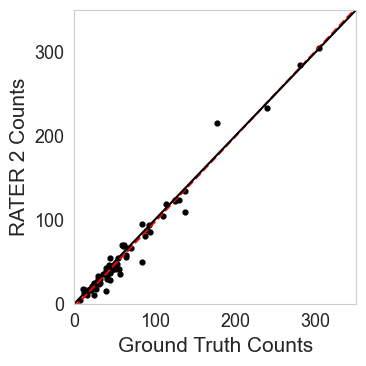

In [57]:
# Rater B
axis_lim = [0,350]

savename = '220605_MPX_JAMADerm_N18_v6_Scatter_Rater2_Rater1_v4'
savefig = False
showfig = True

#Regression line
linear_regress_fit = linregress(algo_comparison_counts_df['Rater 1'], algo_comparison_counts_df['Rater 2'])
x_scatter_line = np.asarray(axis_lim)
y_scatter_line = linear_regress_fit.slope*x_scatter_line + linear_regress_fit.intercept

print('y = '+str(np.around(linear_regress_fit.slope,2))+'x + '+str(np.around(linear_regress_fit.intercept,2)))
print('R^2 = '+str(np.around(linear_regress_fit.rvalue**2,2)))

plt.figure(figsize=(4,4))

plt.scatter(algo_comparison_counts_df['Rater 1'],
            algo_comparison_counts_df['Rater 2'],
            color="0.0", s=12)

plt.plot(x_scatter_line,
         y_scatter_line,color="red",linestyle='--')

plt.plot(axis_lim,axis_lim,'k-')

plt.xlabel("Ground Truth Counts", fontsize=15)
plt.ylabel("RATER 2 Counts", fontsize=15)
plt.xlim(axis_lim)
plt.ylim(axis_lim)
plt.yticks([0,100,200,300])
plt.xticks([0,100,200,300])

plt.tick_params(labelsize=13)

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

y = 1.07x + 5.26
R^2 = 0.92


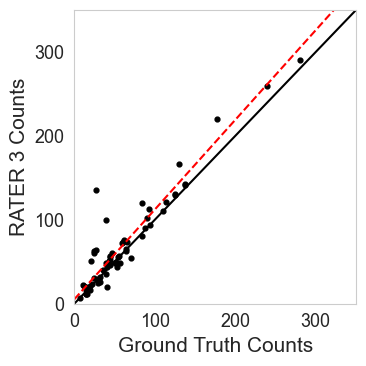

In [58]:
# Rater C
axis_lim = [0,350]

savename = '220605_MPX_JAMADerm_N18_v6_Scatter_Rater3_Rater1_v4'
savefig = False
showfig = True

#Regression line
linear_regress_fit = linregress(algo_comparison_counts_df['Rater 1'], algo_comparison_counts_df['Rater 3'])
x_scatter_line = np.asarray(axis_lim)
y_scatter_line = linear_regress_fit.slope*x_scatter_line + linear_regress_fit.intercept

print('y = '+str(np.around(linear_regress_fit.slope,2))+'x + '+str(np.around(linear_regress_fit.intercept,2)))
print('R^2 = '+str(np.around(linear_regress_fit.rvalue**2,2)))

plt.figure(figsize=(4,4))

plt.scatter(algo_comparison_counts_df['Rater 1'],
            algo_comparison_counts_df['Rater 3'],
            color="0.0", s=12)

plt.plot(x_scatter_line,
         y_scatter_line,color="red",linestyle='--')

plt.plot(axis_lim,axis_lim,'k-')

plt.xlabel("Ground Truth Counts", fontsize=15)
plt.ylabel("RATER 3 Counts", fontsize=15)
plt.xlim(axis_lim)
plt.ylim(axis_lim)
plt.yticks([0,100,200,300])
plt.xticks([0,100,200,300])

plt.tick_params(labelsize=13)

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

y = 1.03x + 11.3
R^2 = 0.9


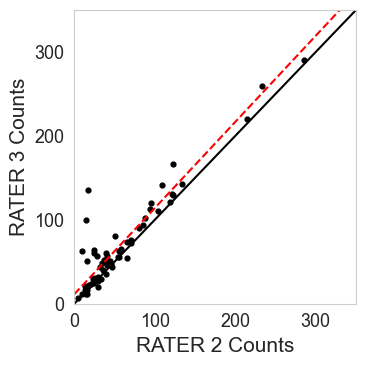

In [59]:
# C vs B
axis_lim = [0,350]

savename = '220605_MPX_JAMADerm_N18_v6_Scatter_Rater3_Rater2_v4'
savefig = False
showfig = True

#Regression line
linear_regress_fit = linregress(algo_comparison_counts_df['Rater 2'], algo_comparison_counts_df['Rater 3'])
x_scatter_line = np.asarray(axis_lim)
y_scatter_line = linear_regress_fit.slope*x_scatter_line + linear_regress_fit.intercept

print('y = '+str(np.around(linear_regress_fit.slope,2))+'x + '+str(np.around(linear_regress_fit.intercept,2)))
print('R^2 = '+str(np.around(linear_regress_fit.rvalue**2,2)))

plt.figure(figsize=(4,4))

plt.scatter(algo_comparison_counts_df['Rater 2'],
            algo_comparison_counts_df['Rater 3'],
            color="0.0", s=12)

plt.plot(x_scatter_line,
         y_scatter_line,color="red",linestyle='--')

plt.plot(axis_lim,axis_lim,'k-')

plt.xlabel("RATER 2 Counts", fontsize=15)
plt.ylabel("RATER 3 Counts", fontsize=15)
plt.xlim(axis_lim)
plt.ylim(axis_lim)
plt.yticks([0,100,200,300])
plt.xticks([0,100,200,300])

plt.tick_params(labelsize=13)

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

### Histogram of images per patient

In [60]:
images_per_patient = {}
for key in h5_paths_dict:
    images_per_patient[key] = len(h5_paths_dict[key])

In [61]:
imgs_per_patient_df = pd.DataFrame(images_per_patient, index=[0]).transpose()

In [62]:
imgs_per_patient_df_sorted = pd.DataFrame.sort_values(imgs_per_patient_df,0)
imgs_per_patient_df_sorted.index.tolist()

['213',
 'MPX subject coming from Dekese (Not enrolled)',
 '051302',
 '051307',
 'Kole3',
 '247',
 'Kole2',
 'Kole1',
 '221',
 '248',
 '239',
 '051301',
 '051309',
 '227',
 '238',
 '236',
 '051310',
 '051308']

In [63]:
barplot_labels = imgs_per_patient_df_sorted.index.tolist()
barplot_labels[1] = 'MPX subject'

In [64]:
patient_id_list = []
for id in range(1,19):
    patient_id_list.extend([str(id)])

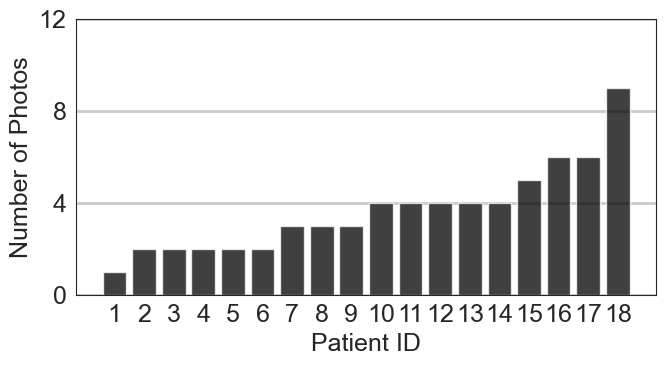

,0
0.00,1.0
0.25,2.0
0.50,3.5
0.75,4.0
1.00,9.0


In [65]:
savename = '220605_MPX_JAMADerm_N18_v6_photoCountsPerPatient_v4'
savefig = False
showfig = True

sns.set_style("white")

plt.figure(figsize=(7,4))
plt.bar(patient_id_list, list(imgs_per_patient_df_sorted[0]), color='0.0', alpha=0.75)
#plt.xticks(rotation = 90)
plt.grid(axis='y',linestyle='-', linewidth=2)
#plt.title('Photos per Patient (N='+str(len(patient_name_list))+', n='+str(len(lesion_counts_df))+')')
plt.ylim([0,12])
plt.ylabel('Number of Photos')
plt.xlabel('Patient ID')

plt.yticks([0,4,8,12])

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

imgs_per_patient_df_sorted.quantile([0,0.25,0.5,0.75,1])

In [66]:
imgs_per_patient_df_sorted_csv = imgs_per_patient_df_sorted.copy()
imgs_per_patient_df_sorted_csv['Patient ID'] = list(range(1,19))

photos_per_patient_df = imgs_per_patient_df_sorted_csv.rename({0: 'Photos per Patient', 1: 'Patient ID'}, axis='columns')
photos_per_patient_df.to_csv(save_root + '220607_MPX_JAMADerm_N18_v6_PhotosPerPatientID.csv',index=True)

### Contour Overlays

In [67]:
def seg_contour_overlay(mask_list,
                        image,
                        line_size=4,
                        fig_size=(16,16),
                        thresh=0.5,
                        color_list = ['blue','lime','magenta','yellow','red'],
                        save_fig=False,
                        save_name='overlay.jpg',
                        show_fig=True,
                        title='Contour Overlay',
                        save_fig_dpi=150,
                        contour_alpha=0.75
                       ):
    
    if torch.is_tensor(image):
        image = np.moveaxis(image.squeeze().cpu().numpy(), 0, -1)
    
    contour_list = []
    for mask in mask_list:
        contour_list.extend([measure.find_contours(mask, thresh)])
    
    fig, ax = plt.subplots(figsize=fig_size)
    image_new = image.copy()
    image[:,:,0] = image_new[:,:,2]
    image[:,:,2] = image_new[:,:,0]
    ax.imshow(image, cmap=plt.cm.gray, interpolation=None)
    
    color_select = 0
    for mask_contour in contour_list:
        for contour in mask_contour:
            ax.plot(contour[:, 1], contour[:, 0], linewidth=line_size, color=color_list[color_select],alpha=contour_alpha)
        color_select+=1

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title)
    if save_fig:
        plt.savefig(save_name, dpi=save_fig_dpi, bbox_inches='tight', pad_inches = 0)
    if show_fig:
        plt.show()
    else:
        plt.close()

In [68]:
contour_save_root = r'.\MaskRCNN_LesionContours_nms_patch' + os.sep
os.makedirs(contour_save_root, exist_ok=True)

prediction_dir =  data_root + 'MaskRCNN_prediction_results_nms_patch' + os.sep

full_prediction_list = sorted(glob.glob(prediction_dir + os.sep + '**' + os.sep + '*.h5', recursive=True))

In [69]:
if True:
    for img_no in range(len(full_prediction_list)):
        current_filename = full_prediction_list[img_no]
        current_photo_name = os.path.basename(current_filename)[:-20]

        with h5py.File(current_filename, 'r') as hdf:
            current_img = np.asarray(hdf['img'])
            current_gt = np.asarray(hdf['gt_mask'])
            current_predict_mask = np.asarray(hdf['pr_mask_optimum'])

        if False:
            plt.figure(figsize=(12,12))
            plt.subplot(1,3,1)
            plt.imshow(current_img)
            plt.subplot(1,3,2)
            plt.imshow(current_gt,cmap='gray')
            plt.subplot(1,3,3)
            plt.imshow(current_predict_mask,cmap='gray')
            plt.show()

        gt_mask_labelled = measure.label(current_gt)
        pr_mask_labelled = measure.label(current_predict_mask)

        overlap_mask = np.zeros(current_predict_mask.shape)
        pr_missing_mask = np.zeros(current_predict_mask.shape)
        gt_missing_mask = np.zeros(current_gt.shape)


        for region_label in range (1,len(np.unique(pr_mask_labelled))):
#             print(current_predict_mask.shape)
            current_region_mask = np.zeros(current_predict_mask.shape)
            current_region_mask[pr_mask_labelled == region_label] = 1

            if sum(current_gt[current_region_mask == 1]) > 0:
                overlap_mask[current_region_mask == 1] = 1
            else:
                pr_missing_mask[current_region_mask == 1] = 1

        for region_label in range (1,len(np.unique(gt_mask_labelled))):
            current_region_mask = np.zeros(current_predict_mask.shape)
            current_region_mask[gt_mask_labelled == region_label] = 1

            if sum(current_predict_mask[current_region_mask == 1]) == 0:
                gt_missing_mask[current_region_mask == 1] = 1

        seg_contour_overlay([overlap_mask,pr_missing_mask,gt_missing_mask],
                        current_img,
                        line_size=3,
                        fig_size=(16,16),
                        thresh=0.5,
                        color_list = ['lime','blue','magenta','yellow','red'],
                        save_fig=True,
                        save_name=contour_save_root + current_photo_name + 'ColorCodedOverlay.jpg',
                        show_fig=False,
                        title='',
                        save_fig_dpi=150,
                        contour_alpha=1)

---
## Dice!

In [70]:
dice_list = []
dice_list_masked = []
for key in algorithm_stats:
    dice_list.extend(algorithm_stats[key]['dice_optimum'])
    dice_list_masked.extend(algorithm_stats[key]['dice_optimum_masked'])

meanline!


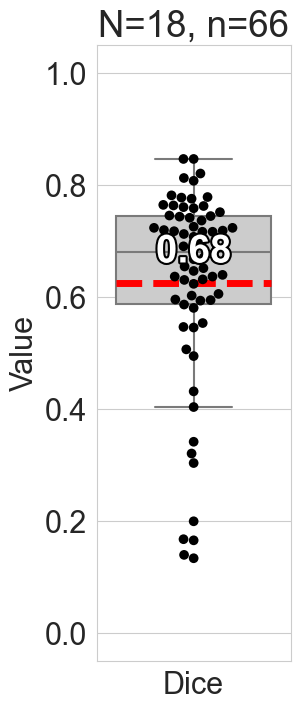

,Dice
0.00,0.13400
0.25,0.58875
0.50,0.68000
0.75,0.74475
1.00,0.84700


In [73]:
# Normal

dice_df = pd.DataFrame(
    {
        'Dice':dice_list,
    }
)

boxplot_full_set_v2(dice_df,
                 figsize=(2.5,8),
                 fontsize=22,
                 swarmsize=7,
                 savename=save_root+"220605_MPX_JAMADerm_N18_v6_Dice_v4",
                 title='N=18, n=66',
                 titlewrap=25,
                 xlabel='',
                 ylabel='Value',
                 ylim=(-0.05,1.05),
                 colors = ['0.8','0.8'],
                 #colors = ["#6BA3F0"],
                 swarmpalette=["0.0"],
                 median_labels=True,
                 median_color='white',
                 median_outline=True,
                 median_outline_color='0.0',
                 median_fontsize=28,
                 show_means=True,
                 meanline=True,
                 meanprops={"c":"red",
                           "ls":"--",
                           'linewidth':'5'},
                 savefig=False
                )

dice_df.quantile([0,0.25,0.5,0.75,1])

meanline!


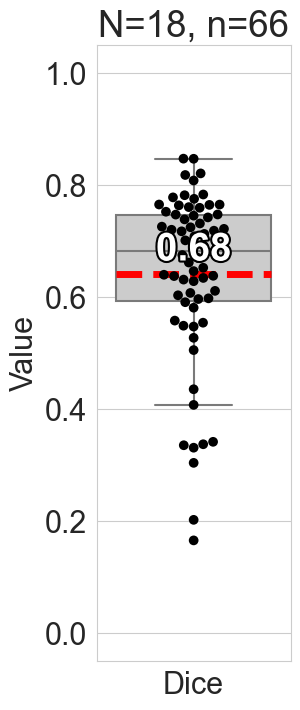

,Dice
0.00,0.165872
0.25,0.592614
0.50,0.683512
0.75,0.747817
1.00,0.847565


In [74]:
# Masked

dice_df = pd.DataFrame(
    {
        'Dice':dice_list_masked,
    }
)

boxplot_full_set_v2(dice_df,
                 figsize=(2.5,8),
                 fontsize=22,
                 swarmsize=7,
                 savename=save_root+"220606_MPX_JAMADerm_N18_v6_DiceMasked_v4",
                 title='N=18, n=66',
                 titlewrap=25,
                 xlabel='',
                 ylabel='Value',
                 ylim=(-0.05,1.05),
                 colors = ['0.8','0.8'],
                 #colors = ["#6BA3F0"],
                 swarmpalette=["0.0"],
                 median_labels=True,
                 median_color='white',
                 median_outline=True,
                 median_outline_color='0.0',
                 median_fontsize=28,
                 show_means=True,
                 meanline=True,
                 meanprops={"c":"red",
                           "ls":"--",
                           'linewidth':'5'},
                 savefig=False
                )

dice_df.quantile([0,0.25,0.5,0.75,1])

In [214]:
print(np.mean(dice_df))

0.5551019455297475


In [215]:
# Save Dice and pixel counts to csv

dice_df_csv = pd.DataFrame(
    {
        'Image Names':image_name_list,
        'Dice':dice_list,
        'Dice (Skin Only)':dice_list_masked,
        'Total Pixels: Skin':np.asarray(pixel_counts_skin_list,'int32'),
        'Total Pixels: Ground Truth Lesions':np.asarray(pixel_counts_gtMasked_list,'int32'),
        'Total Pixels: Predicted Lesions':np.asarray(pixel_counts_prMasked_list,'int32')
    }
)

dice_df_csv.to_csv(save_root + '220607_MPX_JAMADerm_N18_v6_SegmentationDice.csv',index=False)

---
## Intra-Rater (not used in 1st submission!)

In [216]:
repeat_count_mask_root = data_root + 'gt_counts' + os.sep + 'repeats' + os.sep

#count_masks_AM = sorted(glob.glob(count_mask_root + 'AM' + os.sep + '**' + os.sep + '*.png', recursive=True))
repeat_count_masks_DWH = sorted(glob.glob(repeat_count_mask_root + 'DWH' + os.sep + '**' + os.sep + '*.png', recursive=True))
#count_masks_ZC = sorted(glob.glob(count_mask_root + 'ZC' + os.sep + '**' + os.sep + '*.png', recursive=True))

In [217]:
repeat_lesion_count_dict = {
    'Image Names': image_name_list,
    #'AM': count_all_lesions(count_masks_AM),
    'DWH': count_all_lesions(repeat_count_masks_DWH),
    #'ZC': count_all_lesions(count_masks_ZC),
}

In [218]:
repeat_lesion_counts_df = pd.DataFrame.from_dict(repeat_lesion_count_dict)
repeat_lesion_counts_df

,Image Names,DWH
0,051301 D2_06,32
1,051301 D2_07,70
2,051301 D2_08,49
3,051301 D8_02,138
4,051302 D2_01,28
5,051302 D2_02,38
6,051307 010,14
7,051307 012,16
8,051308 001,95
9,051308 004,46


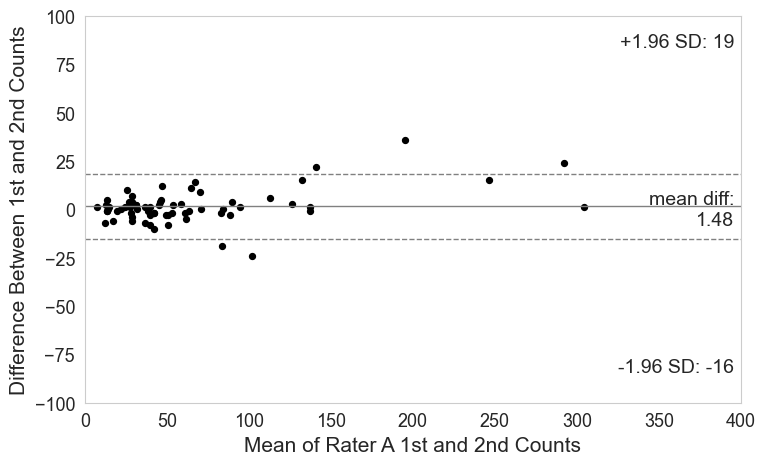

In [219]:
savename = '220528_MPX_Counting_L1O_N18_DEIDENT_v5_RaterA_Repeat_v1'
savefig = False
showfig = True

sns.set_style("whitegrid", {'axes.grid' : False})
scatter_kwds = {
    's': 18,
    'c': 'black'
}

f, ax = plt.subplots(1, figsize = (8,5))
sm.graphics.mean_diff_plot(np.asarray(repeat_lesion_count_dict['DWH']),
                           np.asarray(algo_comparison_counts_df['Rater 1']), ax = ax,scatter_kwds=scatter_kwds)

plt.title('')
plt.xlim([0,400])
plt.ylim([-100,100])
plt.ylabel('Difference Between 1st and 2nd Counts')
plt.xlabel('Mean of Rater A 1st and 2nd Counts')

plt.tight_layout()

if savefig:
    plt.savefig(save_root + savename + '.png', dpi=150, bbox_inches='tight')
    plt.savefig(save_root + savename + '.pdf', dpi=150, bbox_inches='tight')
if showfig:
    plt.show()
else:
    plt.close()

In [220]:
np.mean(dice_df)

0.5551019455297475